# Asynchronous checkpoints and failure boundaries

Runnable locally on CPU or on a Cloud TPU VM.

- Distinguish requested, completed, verified and published checkpoint state.
- Continue a functional update while an asynchronous writer is alive.
- Recover from the last accepted checkpoint after an interrupted publication.
- Surface an asynchronous failure before announcing a checkpoint.

Your training loop says “saved,” then the process disappears. Which step can you safely resume? We will separate an asynchronous save request, completed storage work and the application’s announcement of a recoverable checkpoint. You will interrupt publication deliberately and show which state recovery selects.

## The idea

Asynchronous saving overlaps writing with training. A snapshot moves through requested, writing, completed and accepted states. Recovery must select a checkpoint whose completion and validity satisfy the actual storage contract.

## Distinguish a save request from a recovery point

Imagine live training reaches step 42 while a snapshot of step 40 is still being written. The live progress log does not make step 42 recoverable. Failure before the pending snapshot is accepted may leave an earlier checkpoint as the valid choice.

Keep completion signals separate from the record used to select accepted snapshots. Validate required files and metadata before making a new snapshot eligible. Also ensure live training cannot mutate the snapshot's intended contents during writing.

The saved/live/accepted bars represent different boundaries. Their gaps describe work at risk of replay or loss, not necessarily a defect. Interpret them against the failure location and the checkpoint API's stated guarantees.

### Pause and reason

Can a “save requested” message justify deleting the previous accepted checkpoint?

<details><summary>Compare your reasoning</summary>

No. The replacement may never complete or validate. Retention should preserve a recoverable accepted checkpoint until the replacement meets the acceptance contract.

</details>

## Define a completed training boundary

Let the completed training step be $s$. Our state contains a weight vector and that step counter. A snapshot at $s=1$ must restore the vector belonging to that step, even if the live computation advances to $s=2$. The example adds the same known increment to every weight, so an independent array comparison can identify the snapshot without relying on a decreasing training loss.

A real training snapshot also includes optimizer memory, random state and input position from the preceding lessons. Asynchronous writing changes when storage finishes; it does not reduce the state that must be captured.

## Separate save latency from acceptance

The timer before and after save measures the blocking part of the call. A second interval includes our continuing update and the remaining completion wait. These intervals are adjacent in one run, so their sum describes this application’s request-to-completion boundary. Neither isolates disk throughput.

Keep the checkpointer alive until its work finishes. A quickly returned call can already be finished for a small snapshot; do not require a race to reproduce. The invariant we control is that the application does not update its accepted-checkpoint manifest before completion and restoration checks.

## Publish a checkpoint you can actually restore

After waiting, restore against an explicit target and compare the step and every saved value with the snapshot. Write a new manifest to a temporary sibling and replace the old manifest only after the checks pass. On the local filesystem used here this avoids a reader seeing a half-written JSON file.

A rename alone is not a universal durability or distributed-consistency protocol. Object stores, power failures, concurrent writers and multiple hosts need storage-specific guarantees. Our local manifest is an instructional boundary around a single writer, not a replacement for a production checkpoint manager.

## Practice interruption without relying on lucky timing

The second checkpoint is fully written, but an injected exception prevents application publication. Recovery still selects step one through the unchanged manifest. Step two exists on disk yet is not selected by this application. This distinction explains why “directory exists” is a weak recovery test.

The extra failure experiment injects an exception in a finalization callback. The exception is observed when waiting; no manifest is published for that attempt. It exercises error propagation after finalization, not a claim to reproduce every disk failure. Preserve the old accepted checkpoint until the new one is accepted.

## Translate the boundary into an operational rule

Log the requested step, completed step and accepted step separately. If a job exits with an outstanding save, wait during orderly shutdown; if it dies abruptly, resume from the last accepted artifact and expect to repeat work after that step. Record the replay policy rather than silently claiming no work was lost.

When a restore differs, compare sample IDs and state before tuning tolerances. A different next batch, reset optimizer or mismatched package/data contract is a different trajectory, even if the restored weights look reasonable.

## Define functional state and publication

Create a Python file in the course environment. Add this block after the preceding block, then run the assembled file.

In [1]:
# Step 1 — Define functional state and publication: The manifest has its own acceptance boundary.
# Import json for this computation.
import json
import tempfile
import time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
import orbax.checkpoint as ocp
# Read or serialize artifact data on disk (`root`).
root=Path(tempfile.mkdtemp(prefix='jax-async-lesson-'))
# Function `transition(state)` implementing this stage's computation:
def transition(state):
    # Return `{'weight': state['weight'] + 0.25, 'step': state['step'] + 1}` to the caller.
    return {'weight':state['weight']+.25,'step':state['step']+1}
# Function `publish(path, step)` implementing this stage's computation:
def publish(path, step):
    # Evaluate `pending` from the current inputs and state.
    pending=root/'LATEST.pending'
    # Read or serialize artifact data on disk (``).
    pending.write_text(json.dumps({'path':str(path),'step':step}))
    # Run `pending.replace` to perform the next check or state transition.
    pending.replace(root/'LATEST.json')
# Function `accepted()` implementing this stage's computation:
def accepted():
    # Return `json.loads((root / 'LATEST.json').read_text())` to the caller.
    return json.loads((root/'LATEST.json').read_text())

The manifest has its own acceptance boundary. State updates return new arrays so later work cannot redefine the snapshot.

## Save, continue and verify

Create a Python file in the course environment. Add this block after the preceding block, then run the assembled file.

In [2]:
# Step 2 — Save, continue and verify: Wait on the real background writer, restore against the snapshot...
# Initialize array `state` with explicit values and shape.
state={'weight':jnp.arange(1024,dtype=jnp.float32),'step':jnp.array(0,jnp.int32)}
# Run `transition` to compute `snapshot`.
snapshot=transition(state)
# Evaluate `path` from the current inputs and state.
path=root/'step_1'
# Record execution timing or profiler trace in `t0`.
t0=time.perf_counter()
# Enter `ocp.AsyncCheckpointer(ocp.StandardCheckpointH` context block:
with ocp.AsyncCheckpointer(ocp.StandardCheckpointHandler()) as cp:
    # Run `cp.save` to perform the next check or state transition.
    cp.save(path,args=ocp.args.StandardSave(snapshot))
    # Record execution timing or profiler trace in `returned`.
    returned=time.perf_counter()
    # Verify contract: `not (root / 'LATEST.json').exists()`.
    assert not (root/'LATEST.json').exists()
    # Run `transition` to compute `live`.
    live=transition(snapshot)
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Record execution timing or profiler trace in `committed`.
    committed=time.perf_counter()
    # Run `cp.restore` to compute `restored`.
    restored=cp.restore(path,args=ocp.args.StandardRestore(snapshot))
    # Verify that computed values match the expected reference within numerical tolerance.
    np.testing.assert_array_equal(restored['weight'],snapshot['weight'])
    # Verify that the output satisfies the expected shape, finite-value, or numerical contract.
    assert int(restored['step'])==1 and int(live['step'])==2
    # Run `publish` to perform the next check or state transition.
    publish(path,1)
# Evaluate `report` from the current inputs and state.
report={'save_call_seconds':returned-t0,'remaining_work_and_wait_seconds':committed-returned,
        'accepted_step':accepted()['step'],'live_step':int(live['step'])}
# Verify contract: `report['accepted_step'] == 1`.
assert report['accepted_step']==1

Wait on the real background writer, restore against the snapshot contract and publish only after the comparison passes.

## Interrupt publication deliberately

Create a Python file in the course environment. Add this block after the preceding block, then run the assembled file.

In [3]:
# A deliberately interrupted application publication leaves the previous commit selected.
unpublished=root/'step_2'
# Enter `ocp.AsyncCheckpointer(ocp.StandardCheckpointH` context block:
with ocp.AsyncCheckpointer(ocp.StandardCheckpointHandler()) as cp:
    # Run `cp.save` to perform the next check or state transition.
    cp.save(unpublished,args=ocp.args.StandardSave(live))
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Run the boundary check and catch the expected exception:
    try:
        raise RuntimeError('injected interruption before updating LATEST')
    except RuntimeError:
        pass
# Verify contract: `accepted()['step'] == 1`.
assert accepted()['step']==1
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Run `cp.restore` to compute `previous`.
    previous=cp.restore(accepted()['path'],target=snapshot)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(previous['weight'],snapshot['weight'])
# Verify contract: `int(previous['step']) == 1`.
assert int(previous['step'])==1
# Print the observed values to compare against the expected result.
print('Checkpoint workspace:',root)
# Print diagnostic summary of the computed outputs.
print(json.dumps(report,indent=2))
# Print diagnostic summary of the computed outputs.
print('Unpublished step 2 exists; application recovery still selects verified step 1.')

Checkpoint workspace: /var/folders/mp/_mq7srqx2y10p5nhjz9m7hj40000gn/T/jax-async-lesson-33ybvelp
{
  "save_call_seconds": 0.0038055842742323875,
  "remaining_work_and_wait_seconds": 0.015162499621510506,
  "accepted_step": 1,
  "live_step": 2
}
Unpublished step 2 exists; application recovery still selects verified step 1.


The injected application interruption leaves the old accepted checkpoint intact even though a newer directory exists.

## Run the example

In [4]:
# Step 1 — Define functional state and publication: The manifest has its own acceptance boundary.
# Import json for this computation.
import json
import tempfile
import time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
import orbax.checkpoint as ocp
# Read or serialize artifact data on disk (`root`).
root=Path(tempfile.mkdtemp(prefix='jax-async-lesson-'))
# Function `transition(state)` implementing this stage's computation:
def transition(state):
    # Return `{'weight': state['weight'] + 0.25, 'step': state['step'] + 1}` to the caller.
    return {'weight':state['weight']+.25,'step':state['step']+1}
# Function `publish(path, step)` implementing this stage's computation:
def publish(path, step):
    # Evaluate `pending` from the current inputs and state.
    pending=root/'LATEST.pending'
    # Read or serialize artifact data on disk (``).
    pending.write_text(json.dumps({'path':str(path),'step':step}))
    # Run `pending.replace` to perform the next check or state transition.
    pending.replace(root/'LATEST.json')
# Function `accepted()` implementing this stage's computation:
def accepted():
    # Return `json.loads((root / 'LATEST.json').read_text())` to the caller.
    return json.loads((root/'LATEST.json').read_text())

# Step 2 — Save, continue and verify: Wait on the real background writer, restore against the snapshot...
# Initialize array `state` with explicit values and shape.
state={'weight':jnp.arange(1024,dtype=jnp.float32),'step':jnp.array(0,jnp.int32)}
# Run `transition` to compute `snapshot`.
snapshot=transition(state)
# Evaluate `path` from the current inputs and state.
path=root/'step_1'
# Record execution timing or profiler trace in `t0`.
t0=time.perf_counter()
# Enter `ocp.AsyncCheckpointer(ocp.StandardCheckpointH` context block:
with ocp.AsyncCheckpointer(ocp.StandardCheckpointHandler()) as cp:
    # Run `cp.save` to perform the next check or state transition.
    cp.save(path,args=ocp.args.StandardSave(snapshot))
    # Record execution timing or profiler trace in `returned`.
    returned=time.perf_counter()
    # Verify contract: `not (root / 'LATEST.json').exists()`.
    assert not (root/'LATEST.json').exists()
    # Run `transition` to compute `live`.
    live=transition(snapshot)
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Record execution timing or profiler trace in `committed`.
    committed=time.perf_counter()
    # Run `cp.restore` to compute `restored`.
    restored=cp.restore(path,args=ocp.args.StandardRestore(snapshot))
    # Verify that computed values match the expected reference within numerical tolerance.
    np.testing.assert_array_equal(restored['weight'],snapshot['weight'])
    # Verify that the output satisfies the expected shape, finite-value, or numerical contract.
    assert int(restored['step'])==1 and int(live['step'])==2
    # Run `publish` to perform the next check or state transition.
    publish(path,1)
# Evaluate `report` from the current inputs and state.
report={'save_call_seconds':returned-t0,'remaining_work_and_wait_seconds':committed-returned,
        'accepted_step':accepted()['step'],'live_step':int(live['step'])}
# Verify contract: `report['accepted_step'] == 1`.
assert report['accepted_step']==1

# A deliberately interrupted application publication leaves the previous commit selected.
unpublished=root/'step_2'
# Enter `ocp.AsyncCheckpointer(ocp.StandardCheckpointH` context block:
with ocp.AsyncCheckpointer(ocp.StandardCheckpointHandler()) as cp:
    # Run `cp.save` to perform the next check or state transition.
    cp.save(unpublished,args=ocp.args.StandardSave(live))
    # Run `cp.wait_until_finished` to perform the next check or state transition.
    cp.wait_until_finished()
    # Run the boundary check and catch the expected exception:
    try:
        raise RuntimeError('injected interruption before updating LATEST')
    except RuntimeError:
        pass
# Verify contract: `accepted()['step'] == 1`.
assert accepted()['step']==1
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Run `cp.restore` to compute `previous`.
    previous=cp.restore(accepted()['path'],target=snapshot)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(previous['weight'],snapshot['weight'])
# Verify contract: `int(previous['step']) == 1`.
assert int(previous['step'])==1
# Print the observed values to compare against the expected result.
print('Checkpoint workspace:',root)
# Print diagnostic summary of the computed outputs.
print(json.dumps(report,indent=2))
# Print diagnostic summary of the computed outputs.
print('Unpublished step 2 exists; application recovery still selects verified step 1.')

Checkpoint workspace: /var/folders/mp/_mq7srqx2y10p5nhjz9m7hj40000gn/T/jax-async-lesson-3i2oesip
{
  "save_call_seconds": 0.001818208023905754,
  "remaining_work_and_wait_seconds": 0.008865791838616133,
  "accepted_step": 1,
  "live_step": 2
}
Unpublished step 2 exists; application recovery still selects verified step 1.


Expected: The accepted step remains $1$ while the live state reaches $2$. A real local checkpoint restores the saved vector. Both timing intervals are observed and vary by machine.

## A live step can be ahead of the accepted checkpoint

Predict: After the publication interruption, which step will application recovery select?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: A live step can be ahead of the accepted checkpoint
# Evaluate `visual_data` from the current inputs and state.
visual_data={'kind':'bar','labels':['saved snapshot','live state','accepted checkpoint'],'ylabel':'completed step','series':[{'label':'local publication experiment','y':[int(snapshot["step"]),int(live["step"]),report["accepted_step"]]}]}

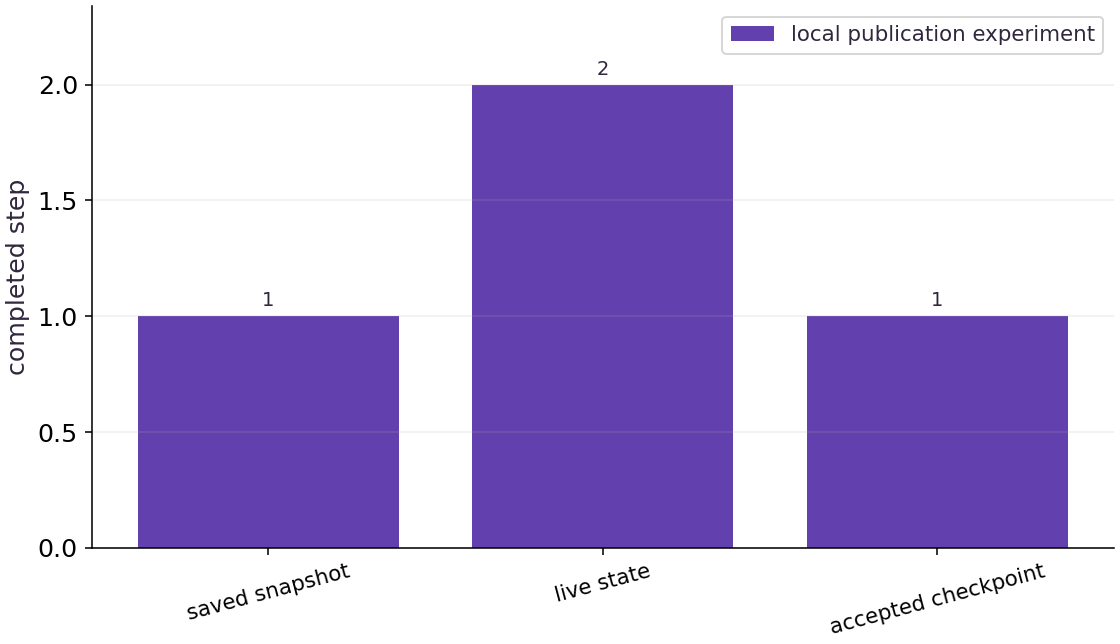

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal labels name three different state positions; the vertical axis is a completed-step count, not elapsed time. The saved snapshot and accepted checkpoint both have height $1$, while the live computation reaches $2$. Equal bars here mean equal step counters.

The gap of one step is intentional. It shows work that the live process has completed but the application has not accepted as its recovery point. The failed publication does not move the accepted bar to two merely because a newer directory is present.

### Connect it to the computation

The code verifies the saved vector and then injects an interruption before publishing the next checkpoint. Recovery consults the earlier manifest and restores the earlier vector. The full state comparison, rather than bar height alone, establishes which values were restored.

This plot is a local controlled failure experiment. It does not measure checkpoint bandwidth, simulate power loss or establish multi-host atomicity. Inspect the separately recorded timing intervals and exception output for those different questions.

## Trigger an asynchronous error

Predict: If finalization reports an error, should directory existence justify announcing success?

In [7]:
# Experiment — Trigger an asynchronous error: The controlled failure happens in the finalization callback.
def injected_failure():
    raise RuntimeError('injected finalization callback failure')
# Evaluate `failed_path` from the current inputs and state.
failed_path=root/'callback_failure'
# Run `ocp.AsyncCheckpointer` to compute `cp`.
cp=ocp.AsyncCheckpointer(ocp.StandardCheckpointHandler(),async_options=ocp.options.AsyncOptions(post_finalization_callback=injected_failure))
# Run the boundary check and catch the expected exception:
try:
    cp.save(failed_path,args=ocp.args.StandardSave(live))
    # Run the boundary check and catch the expected exception:
    try:
        cp.wait_until_finished()
    except RuntimeError as error:
        assert 'injected' in str(error)
        print('Expected background failure surfaced:',error)
    else:
        raise AssertionError('background error was hidden')
finally:
    cp.close()
# Verify contract: `accepted()['step'] == 1`.
assert accepted()['step']==1

Expected background failure surfaced: injected finalization callback failure


Expected: An intentional error log and caught RuntimeError; the accepted step is unchanged.

The controlled failure happens in the finalization callback. Some storage may already exist; the application still requires successful completion and verification before accepting it.

## Your exercise

Verify and publish the already written second checkpoint. Restore it and compare the next functional transition against the live state. Keep the original snapshot unchanged.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `ocp.StandardCheckpointer(...)` — Call `ocp.StandardCheckpointer` with your updated parameters or inputs from this lesson's workspace.
- `cp.restore(...)` — Call `cp.restore` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Enter `ocp.StandardCheckpointer()` context block:
2. Run `cp.restore` to compute `verified`.
3. Verify that computed values match the expected reference within numerical tolerance.
4. Verify contract: `int(verified['step']) == 2`.
5. Run `publish` to perform the next check or state transition.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Verify and publish the already written second checkpoint.
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Run `cp.restore` to compute `verified`.
    verified = cp.restore(...)  # TODO: compute verified
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(verified['weight'],live['weight'])
# Verify contract: `int(verified['step']) == 2`.
assert int(verified['step'])  # TODO: complete assertion check
# Run `publish` to perform the next check or state transition.
publish(unpublished,2)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(transition(verified)['weight'],transition(live)['weight'])
# Verify contract: `accepted()['step'] == 2 and int(snapshot['step']) == 1`.
assert accepted()['step']  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Step two verified and accepted; next transition agrees.')
```

In [8]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Verify and publish the already written second checkpoint.
# Enter `ocp.StandardCheckpointer()` context block:
# with ocp.StandardCheckpointer() as cp:
    # Run `cp.restore` to compute `verified`.
#     verified = cp.restore(...)  # TODO: compute verified
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_array_equal(verified['weight'],live['weight'])
# Verify contract: `int(verified['step']) == 2`.
# assert int(verified['step'])  # TODO: complete assertion check
# Run `publish` to perform the next check or state transition.
# publish(unpublished,2)
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_array_equal(transition(verified)['weight'],transition(live)['weight'])
# Verify contract: `accepted()['step'] == 2 and int(snapshot['step']) == 1`.
# assert accepted()['step']  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Step two verified and accepted; next transition agrees.')

## Reference solution

Try your own implementation first.

In [9]:
# Exercise solution: Verify and publish the already written second checkpoint.
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as cp:
    # Run `cp.restore` to compute `verified`.
    verified=cp.restore(unpublished,target=live)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(verified['weight'],live['weight'])
# Verify contract: `int(verified['step']) == 2`.
assert int(verified['step'])==2
# Run `publish` to perform the next check or state transition.
publish(unpublished,2)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(transition(verified)['weight'],transition(live)['weight'])
# Verify contract: `accepted()['step'] == 2 and int(snapshot['step']) == 1`.
assert accepted()['step']==2 and int(snapshot['step'])==1
# Print the observed values to compare against the expected result.
print('Step two verified and accepted; next transition agrees.')

Step two verified and accepted; next transition agrees.


## Keep only a genuinely accepted target · Transfer

Create a manifest pointing to a nonexistent checkpoint in a disposable variable. Write a preflight that rejects it without replacing the real accepted manifest. Explain why a preflight alone cannot prove numerical correctness.

Hint: Check path existence and the declared step before restoration; still compare restored contents afterward.

### How to write: Keep only a genuinely accepted target — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `target(...)` — Call `target` with your updated parameters or inputs from this lesson's workspace.
- `preflight(...)` — Call `preflight` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Guard input contract (`not Path(record['path']).is_dir() or int(record['step']) < 0`) and fail fast if violated.
2. Return `record` to the caller.
3. Run `accepted` to compute `before`.
4. Run the boundary check and catch the expected exception:
5. Verify contract: `accepted() == before`.

**Starter code scaffold (fill in the TODOs):**

```python
# Keep only a genuinely accepted target (Transfer): File presence is a necessary local preflight, not proof that...
def preflight(record):
    # Guard input contract (`not Path(record['path']).is_dir() or int(record['step']) < 0`) and fail fast if violated.
    if not Path(record['path']).is_dir() or int(record['step'])<0:
        raise ValueError('checkpoint target unavailable')
    # Return `record` to the caller.
    return ...  # TODO: return computed result
# Run `accepted` to compute `before`.
before = accepted(...)  # TODO: compute before
# Run the boundary check and catch the expected exception:
try:preflight({'path':str(root/'never_saved'),'step':99})
except ValueError:pass
else:raise AssertionError('missing target accepted')
# Verify contract: `accepted() == before`.
assert accepted()  # TODO: complete assertion check
# Run `preflight` to perform the next check or state transition.
preflight(before)
# Print the observed values to compare against the expected result.
print('Missing target rejected; accepted checkpoint unchanged.')
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Keep only a genuinely accepted target (Transfer): File presence is a necessary local preflight, not proof that...
# def preflight(record):
    # Guard input contract (`not Path(record['path']).is_dir() or int(record['step']) < 0`) and fail fast if violated.
#     if not Path(record['path']).is_dir() or int(record['step'])<0:
#         raise ValueError('checkpoint target unavailable')
    # Return `record` to the caller.
#     return ...  # TODO: return computed result
# Run `accepted` to compute `before`.
# before = accepted(...)  # TODO: compute before
# Run the boundary check and catch the expected exception:
# try:preflight({'path':str(root/'never_saved'),'step':99})
# except ValueError:pass
# else:raise AssertionError('missing target accepted')
# Verify contract: `accepted() == before`.
# assert accepted()  # TODO: complete assertion check
# Run `preflight` to perform the next check or state transition.
# preflight(before)
# Print the observed values to compare against the expected result.
# print('Missing target rejected; accepted checkpoint unchanged.')

## Reference reasoning

File presence is a necessary local preflight, not proof that metadata, data or training state is correct. The restore comparison supplies the stronger check.

In [11]:
# Keep only a genuinely accepted target (Transfer): File presence is a necessary local preflight, not proof that...
def preflight(record):
    # Guard input contract (`not Path(record['path']).is_dir() or int(record['step']) < 0`) and fail fast if violated.
    if not Path(record['path']).is_dir() or int(record['step'])<0:
        raise ValueError('checkpoint target unavailable')
    # Return `record` to the caller.
    return record
# Run `accepted` to compute `before`.
before=accepted()
# Run the boundary check and catch the expected exception:
try:preflight({'path':str(root/'never_saved'),'step':99})
except ValueError:pass
else:raise AssertionError('missing target accepted')
# Verify contract: `accepted() == before`.
assert accepted()==before
# Run `preflight` to perform the next check or state transition.
preflight(before)
# Print the observed values to compare against the expected result.
print('Missing target rejected; accepted checkpoint unchanged.')

Missing target rejected; accepted checkpoint unchanged.


## Checkpoint

A new checkpoint directory exists but the completion wait raises an exception. Which recovery decision follows this lesson’s protocol?

1. Accept the newest directory immediately.
2. Delete the previous checkpoint because save returned.
3. Retain the previous accepted checkpoint and investigate the failed attempt.

## Diagnose

If the accepted step is ahead of the restored state, inspect publication order and the saved step counter. If wait raises, keep that error and the last accepted manifest; do not suppress the error and publish anyway.

## Evidence

Keep the requested/completed/accepted step log, the restored snapshot comparison, interrupted-publication result and surfaced finalization error. Explain why directory presence alone does not establish acceptance.

## Carry forward

- Record save request, completion and acceptance separately.
- Keep the asynchronous writer alive until completion or reported failure.
- Verify a restored next transition before replacing the accepted recovery point.

## Primary references

- [Orbax asynchronous checkpointing](https://orbax.readthedocs.io/en/latest/guides/checkpoint/async_checkpointing.html)